In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
bank = "bank.csv"

In [2]:
# error messaged with semi colon , so used sep =; to read the file 
bank = pd.read_csv(bank, 
                   sep=';',
                   decimal=';',header=0,index_col=None)
                  
                  
                           

In [3]:
bank.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4521 entries, 0 to 4520
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        4521 non-null   int64 
 1   job        4521 non-null   object
 2   marital    4521 non-null   object
 3   education  4521 non-null   object
 4   default    4521 non-null   object
 5   balance    4521 non-null   int64 
 6   housing    4521 non-null   object
 7   loan       4521 non-null   object
 8   contact    4521 non-null   object
 9   day        4521 non-null   int64 
 10  month      4521 non-null   object
 11  duration   4521 non-null   int64 
 12  campaign   4521 non-null   int64 
 13  pdays      4521 non-null   int64 
 14  previous   4521 non-null   int64 
 15  poutcome   4521 non-null   object
 16  y          4521 non-null   object
dtypes: int64(7), object(10)
memory usage: 600.6+ KB


In [4]:
bank


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4516,33,services,married,secondary,no,-333,yes,no,cellular,30,jul,329,5,-1,0,unknown,no
4517,57,self-employed,married,tertiary,yes,-3313,yes,yes,unknown,9,may,153,1,-1,0,unknown,no
4518,57,technician,married,secondary,no,295,no,no,cellular,19,aug,151,11,-1,0,unknown,no
4519,28,blue-collar,married,secondary,no,1137,no,no,cellular,6,feb,129,4,211,3,other,no


In [5]:
bank.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

In [6]:
bank['job'].value_counts()

management       969
blue-collar      946
technician       768
admin.           478
services         417
retired          230
self-employed    183
entrepreneur     168
unemployed       128
housemaid        112
student           84
unknown           38
Name: job, dtype: int64

In [7]:
# I used this to analyse any column variables duplicates like upper case or white space to remove
for column in bank.columns:
     print("\n" + column)
     print(bank[column].value_counts())
    
    # No action required as the below data looks clean


age
34    231
32    224
31    199
36    188
33    186
     ... 
76      2
84      1
81      1
86      1
87      1
Name: age, Length: 67, dtype: int64

job
management       969
blue-collar      946
technician       768
admin.           478
services         417
retired          230
self-employed    183
entrepreneur     168
unemployed       128
housemaid        112
student           84
unknown           38
Name: job, dtype: int64

marital
married     2797
single      1196
divorced     528
Name: marital, dtype: int64

education
secondary    2306
tertiary     1350
primary       678
unknown       187
Name: education, dtype: int64

default
no     4445
yes      76
Name: default, dtype: int64

balance
0       357
2        24
1        15
4        13
23       11
       ... 
3472      1
5527      1
1433      1
1445      1
4094      1
Name: balance, Length: 2353, dtype: int64

housing
yes    2559
no     1962
Name: housing, dtype: int64

loan
no     3830
yes     691
Name: loan, dtype: int64

contac

In [8]:
df = pd.DataFrame(bank)

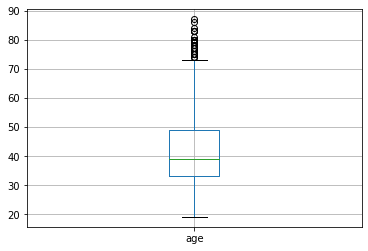

In [9]:
df['age'].plot(kind='box')
plt.grid()
plt.show()


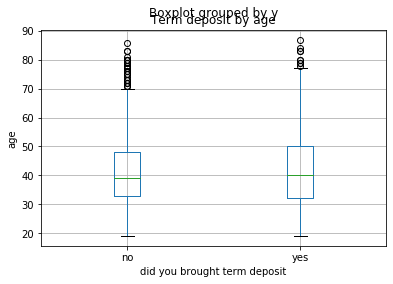

In [10]:
df.boxplot(column='age',by='y')
plt.title('Term deposit by age')
plt.xlabel('did you brought term deposit')
plt.ylabel('age')
plt.show()

In [11]:
# in order to improve accuracy i plan to remove age above 80 as outliers 
df1 = df.drop(df[df.age > 80].index)

In [12]:
df1.shape

(4513, 17)

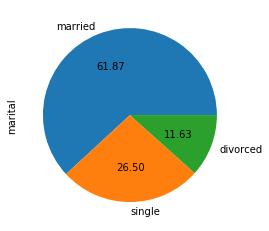

In [13]:
df1['marital']\
    .value_counts()\
    .plot(kind='pie',autopct='%.2f')
plt.show()


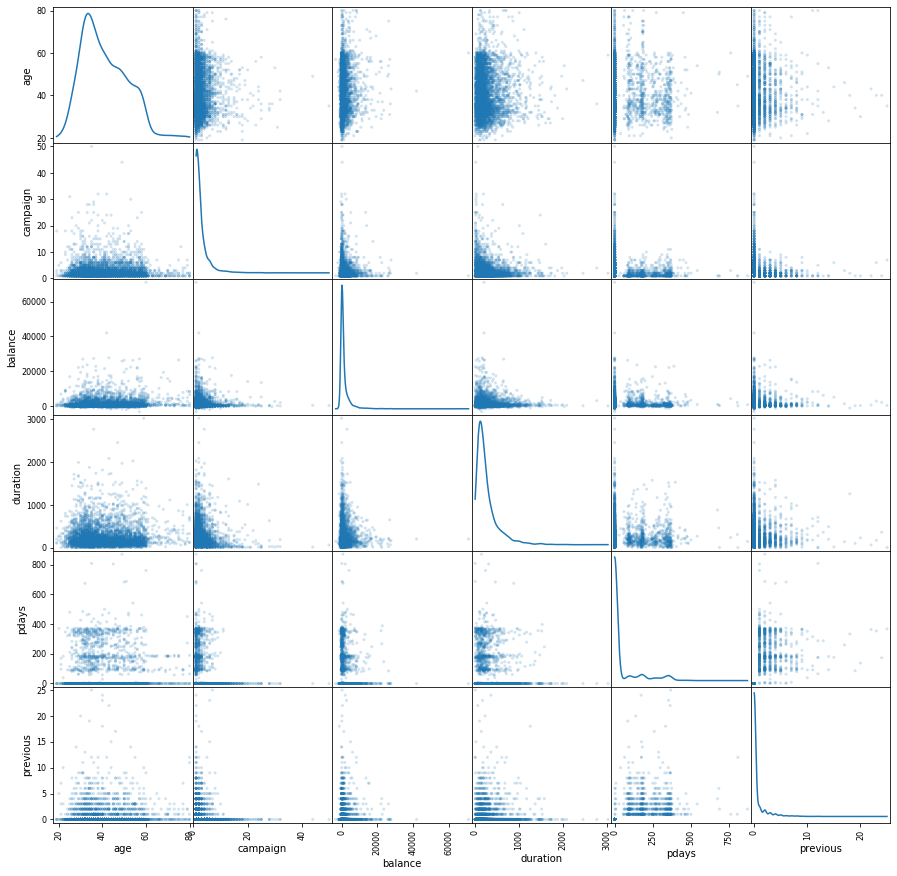

In [14]:
#plot scatter matrix for all numeric variables 

scatter = df1.filter(['age','campaign','balance','duration','pdays','previous',], axis=1)

from pandas.plotting import scatter_matrix
scatter_matrix(scatter,alpha=0.2,figsize=(15,15),diagonal='density')
plt.show()

/opt/anaconda3/lib/python3.7/site-packages/seaborn/categorical.py:3669: UserWarning: The `factorplot` function has been renamed to `catplot`. The original name will be removed in a future release. Please update your code. Note that the default `kind` in `factorplot` (`'point'`) has changed `'strip'` in `catplot`.
  warnings.warn(msg)


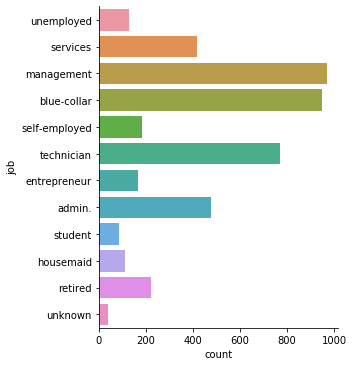

In [15]:

import seaborn as sns
sns.factorplot(y='job',kind="count", data=df1)
plt.show()

In [16]:
df1["c"] = "count"
report = df1[["marital", "y","c"]]\
                    .groupby(["marital", "y",])\
                    .agg("count")
print(report)
report1 = pd.DataFrame(report)
#df = pd.DataFrame(data) 

                 c
marital  y        
divorced no    450
         yes    75
married  no   2517
         yes   275
single   no   1029
         yes   167


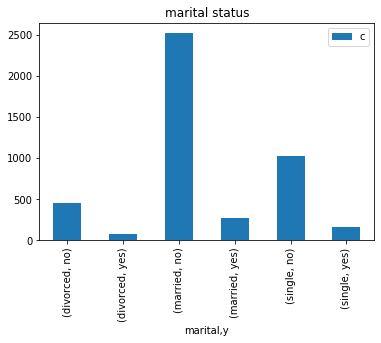

In [17]:
report.plot.bar()
plt.title('marital status')
plt.show()

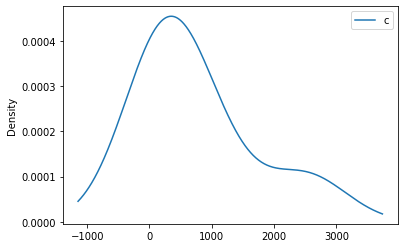

In [18]:
lines = report.plot.density()
#no use of this graph

In [19]:
bank.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4521 entries, 0 to 4520
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        4521 non-null   int64 
 1   job        4521 non-null   object
 2   marital    4521 non-null   object
 3   education  4521 non-null   object
 4   default    4521 non-null   object
 5   balance    4521 non-null   int64 
 6   housing    4521 non-null   object
 7   loan       4521 non-null   object
 8   contact    4521 non-null   object
 9   day        4521 non-null   int64 
 10  month      4521 non-null   object
 11  duration   4521 non-null   int64 
 12  campaign   4521 non-null   int64 
 13  pdays      4521 non-null   int64 
 14  previous   4521 non-null   int64 
 15  poutcome   4521 non-null   object
 16  y          4521 non-null   object
dtypes: int64(7), object(10)
memory usage: 600.6+ KB


In [20]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split

In [21]:
clf = DecisionTreeClassifier()

In [22]:
df1.shape

(4513, 18)

In [23]:
df1.groupby('y').size()
# by looking at the below output around 13% people brought term deposits

y
no     3996
yes     517
dtype: int64

In [24]:
df1["jayresult"] =(df1.y == 'yes')

In [25]:
df1["jayresult"]

0       False
1       False
2       False
3       False
4       False
        ...  
4516    False
4517    False
4518    False
4519    False
4520    False
Name: jayresult, Length: 4513, dtype: bool

In [26]:
df1["jayresult"] =(df1.y == 'yes').astype('int')
# convert true or falst into integers 0 and 1 

In [27]:
#select columns you plan to use for model 
numcols = ['age','balance','duration','campaign','pdays','previous']

In [28]:
categcols = ['marital','education','default','housing','poutcome','job','loan','contact']

In [29]:
df1[categcols]

,marital,education,default,housing,poutcome,job,loan,contact
0,married,primary,no,no,unknown,unemployed,no,cellular
1,married,secondary,no,yes,failure,services,yes,cellular
2,single,tertiary,no,yes,failure,management,no,cellular
3,married,tertiary,no,yes,unknown,management,yes,unknown
4,married,secondary,no,yes,unknown,blue-collar,no,unknown
...,...,...,...,...,...,...,...,...
4516,married,secondary,no,yes,unknown,services,no,cellular
4517,married,tertiary,yes,yes,unknown,self-employed,yes,unknown
4518,married,secondary,no,no,unknown,technician,no,cellular
4519,married,secondary,no,no,other,blue-collar,no,cellular


In [30]:
newcategcol = pd.get_dummies(df1[categcols],drop_first = False)
newcategcol

,marital_divorced,marital_married,marital_single,education_primary,education_secondary,education_tertiary,education_unknown,default_no,default_yes,housing_no,...,job_services,job_student,job_technician,job_unemployed,job_unknown,loan_no,loan_yes,contact_cellular,contact_telephone,contact_unknown
0,0,1,0,1,0,0,0,1,0,1,...,0,0,0,1,0,1,0,1,0,0
1,0,1,0,0,1,0,0,1,0,0,...,1,0,0,0,0,0,1,1,0,0
2,0,0,1,0,0,1,0,1,0,0,...,0,0,0,0,0,1,0,1,0,0
3,0,1,0,0,0,1,0,1,0,0,...,0,0,0,0,0,0,1,0,0,1
4,0,1,0,0,1,0,0,1,0,0,...,0,0,0,0,0,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4516,0,1,0,0,1,0,0,1,0,0,...,1,0,0,0,0,1,0,1,0,0
4517,0,1,0,0,0,1,0,0,1,0,...,0,0,0,0,0,0,1,0,0,1
4518,0,1,0,0,1,0,0,1,0,1,...,0,0,1,0,0,1,0,1,0,0
4519,0,1,0,0,1,0,0,1,0,1,...,0,0,0,0,0,1,0,1,0,0


In [31]:
df1 = pd.concat([df1,newcategcol],axis =1)

In [32]:
df1

,age,job,marital,education,default,balance,housing,loan,contact,day,...,job_services,job_student,job_technician,job_unemployed,job_unknown,loan_no,loan_yes,contact_cellular,contact_telephone,contact_unknown
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,...,0,0,0,1,0,1,0,1,0,0
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,...,1,0,0,0,0,0,1,1,0,0
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,...,0,0,0,0,0,1,0,1,0,0
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,...,0,0,0,0,0,0,1,0,0,1
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,...,0,0,0,0,0,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4516,33,services,married,secondary,no,-333,yes,no,cellular,30,...,1,0,0,0,0,1,0,1,0,0
4517,57,self-employed,married,tertiary,yes,-3313,yes,yes,unknown,9,...,0,0,0,0,0,0,1,0,0,1
4518,57,technician,married,secondary,no,295,no,no,cellular,19,...,0,0,1,0,0,1,0,1,0,0
4519,28,blue-collar,married,secondary,no,1137,no,no,cellular,6,...,0,0,0,0,0,1,0,1,0,0


In [33]:
colall = list(newcategcol.columns)

In [34]:
colall

['marital_divorced',
 'marital_married',
 'marital_single',
 'education_primary',
 'education_secondary',
 'education_tertiary',
 'education_unknown',
 'default_no',
 'default_yes',
 'housing_no',
 'housing_yes',
 'poutcome_failure',
 'poutcome_other',
 'poutcome_success',
 'poutcome_unknown',
 'job_admin.',
 'job_blue-collar',
 'job_entrepreneur',
 'job_housemaid',
 'job_management',
 'job_retired',
 'job_self-employed',
 'job_services',
 'job_student',
 'job_technician',
 'job_unemployed',
 'job_unknown',
 'loan_no',
 'loan_yes',
 'contact_cellular',
 'contact_telephone',
 'contact_unknown']

In [35]:
# create column and data frame for the model 
colmodel = colall + numcols

In [36]:
dfmodeldata = df1[colmodel+['jayresult']]

In [37]:
#let us shuffle the modeldat and take 50% for test data 
dfmodeldata = dfmodeldata.sample(n=len(dfmodeldata),random_state=30)
#dfmodeldata = dfmodeldata.reset_index(drop = True)

In [38]:
dftvdata = dfmodeldata.sample (frac=0.50,random_state=30)

In [39]:
# splittest and validation data for testing and validation 
dftestdata = dftvdata.sample (frac=0.50,random_state=30)

In [40]:
# validation data 
dfvaliddata = dftvdata.drop(dftestdata.index)

In [41]:
dftraindata = dfmodeldata.drop(dftvdata.index)

In [42]:
xtrain = dftraindata[colmodel].values
            

In [43]:
xtrain

array([[  0,   1,   0, ...,   1,  -1,   0],
       [  0,   1,   0, ...,   2,  -1,   0],
       [  0,   1,   0, ...,   2, 190,   1],
       ...,
       [  0,   1,   0, ...,   1,  -1,   0],
       [  0,   0,   1, ...,   5,  84,   1],
       [  1,   0,   0, ...,   1, 293,   1]])

In [44]:
ytrain = dftraindata['jayresult'].values 

In [45]:
ytrain

array([0, 0, 0, ..., 0, 0, 1])

In [46]:
xtestv = dftvdata[colmodel].values

In [47]:
ytestv = dftvdata['jayresult'].values 

In [48]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [49]:
clf = DecisionTreeClassifier()

In [50]:
fit = clf.fit(xtrain, ytrain)

In [51]:
y_pre = fit.predict(xtestv)

In [52]:
cm = confusion_matrix(ytestv, y_pre)

In [53]:
cm

array([[1843,  147],
       [ 173,   93]])

In [54]:
jayreport = classification_report(ytestv, y_pre)

In [55]:
print(jayreport)

              precision    recall  f1-score   support

           0       0.91      0.93      0.92      1990
           1       0.39      0.35      0.37       266

    accuracy                           0.86      2256
   macro avg       0.65      0.64      0.64      2256
weighted avg       0.85      0.86      0.85      2256



In [56]:
dftvdata = dfmodeldata.sample (frac=0.40,random_state=30)
dftraindata = dfmodeldata.drop(dftvdata.index)
xtrain = dftraindata[colmodel].values
ytrain = dftraindata['jayresult'].values 
xtestv = dftvdata[colmodel].values
ytestv = dftvdata['jayresult'].values 
clf = DecisionTreeClassifier()
fit = clf.fit(xtrain, ytrain)
y_pre = fit.predict(xtestv)
cm = confusion_matrix(ytestv, y_pre)
jayreport = classification_report(ytestv, y_pre)
print(jayreport)

              precision    recall  f1-score   support

           0       0.92      0.93      0.92      1588
           1       0.42      0.39      0.40       217

    accuracy                           0.86      1805
   macro avg       0.67      0.66      0.66      1805
weighted avg       0.86      0.86      0.86      1805



In [57]:
dftvdata = dfmodeldata.sample (frac=0.20,random_state=30)
dftraindata = dfmodeldata.drop(dftvdata.index)
xtrain = dftraindata[colmodel].values
ytrain = dftraindata['jayresult'].values 
xtestv = dftvdata[colmodel].values
ytestv = dftvdata['jayresult'].values 
clf = DecisionTreeClassifier()
fit = clf.fit(xtrain, ytrain)
y_pre = fit.predict(xtestv)
cm = confusion_matrix(ytestv, y_pre)
jayreport = classification_report(ytestv, y_pre)
print(jayreport)

              precision    recall  f1-score   support

           0       0.91      0.91      0.91       793
           1       0.34      0.35      0.34       110

    accuracy                           0.84       903
   macro avg       0.62      0.63      0.62       903
weighted avg       0.84      0.84      0.84       903



In [58]:
from sklearn.ensemble import RandomForestClassifier

dftvdata = dfmodeldata.sample (frac=0.50,random_state=30)
dftraindata = dfmodeldata.drop(dftvdata.index)
xtrain = dftraindata[colmodel].values
ytrain = dftraindata['jayresult'].values 
xtestv = dftvdata[colmodel].values
ytestv = dftvdata['jayresult'].values 
rf = RandomForestClassifier (max_depth = 9,random_state=30)
fit = rf.fit(xtrain, ytrain)
y_pre = fit.predict(xtestv)
cm = confusion_matrix(ytestv, y_pre)
jayreport = classification_report(ytestv, y_pre)
print(jayreport)

              precision    recall  f1-score   support

           0       0.90      0.99      0.94      1990
           1       0.66      0.14      0.23       266

    accuracy                           0.89      2256
   macro avg       0.78      0.57      0.59      2256
weighted avg       0.87      0.89      0.86      2256



In [59]:
dftvdata = dfmodeldata.sample (frac=0.40,random_state=30)
dftraindata = dfmodeldata.drop(dftvdata.index)
xtrain = dftraindata[colmodel].values
ytrain = dftraindata['jayresult'].values 
xtestv = dftvdata[colmodel].values
ytestv = dftvdata['jayresult'].values 
rf = RandomForestClassifier (max_depth = 9,random_state=30)
fit = rf.fit(xtrain, ytrain)
y_pre = fit.predict(xtestv)
cm = confusion_matrix(ytestv, y_pre)
jayreport = classification_report(ytestv, y_pre)
print(jayreport)

              precision    recall  f1-score   support

           0       0.89      0.99      0.94      1588
           1       0.71      0.13      0.22       217

    accuracy                           0.89      1805
   macro avg       0.80      0.56      0.58      1805
weighted avg       0.87      0.89      0.85      1805



In [60]:
dftvdata = dfmodeldata.sample (frac=0.20,random_state=30)
dftraindata = dfmodeldata.drop(dftvdata.index)
xtrain = dftraindata[colmodel].values
ytrain = dftraindata['jayresult'].values 
xtestv = dftvdata[colmodel].values
ytestv = dftvdata['jayresult'].values 
rf = RandomForestClassifier (max_depth = 9,random_state=30)
fit = rf.fit(xtrain, ytrain)
y_pre = fit.predict(xtestv)
cm = confusion_matrix(ytestv, y_pre)
jayreport = classification_report(ytestv, y_pre)
print(jayreport)

              precision    recall  f1-score   support

           0       0.89      0.99      0.94       793
           1       0.70      0.13      0.22       110

    accuracy                           0.89       903
   macro avg       0.80      0.56      0.58       903
weighted avg       0.87      0.89      0.85       903



In [61]:
dfmodeldata

,marital_divorced,marital_married,marital_single,education_primary,education_secondary,education_tertiary,education_unknown,default_no,default_yes,housing_no,...,contact_cellular,contact_telephone,contact_unknown,age,balance,duration,campaign,pdays,previous,jayresult
1243,0,1,0,1,0,0,0,1,0,1,...,1,0,0,69,579,230,1,-1,0,0
3462,0,1,0,0,1,0,0,1,0,0,...,0,1,0,34,360,46,1,182,2,0
4047,0,1,0,0,1,0,0,1,0,1,...,0,1,0,75,26452,219,2,-1,0,0
3157,0,1,0,0,1,0,0,1,0,1,...,1,0,0,75,6053,865,2,190,1,0
3539,0,0,1,0,1,0,0,1,0,0,...,1,0,0,28,189,68,2,-1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2477,0,1,0,1,0,0,0,1,0,1,...,1,0,0,53,732,759,2,-1,0,1
1157,0,1,0,0,0,0,1,1,0,1,...,1,0,0,55,23,123,2,-1,0,0
921,0,1,0,0,0,1,0,1,0,0,...,1,0,0,34,136,156,1,-1,0,0
500,0,0,1,0,0,1,0,1,0,1,...,1,0,0,32,12607,203,5,84,1,0
